- After passing all unit tests in test_HDR_functions.ipynb, you can execute HDR_flow.ipynb to run the whole HDR imaging flow
- Folder name can be set according to your need

In [3]:
from pathlib import Path
import os


def find_hw01_root():
    cwd = Path.cwd().resolve()
    for path in (cwd, *cwd.parents):
        if (path / 'code' / 'HDR_functions.ipynb').exists() and (path / 'TestImage').exists():
            return Path(os.path.relpath(path, cwd))

        hw01 = path / 'hw01'
        if (hw01 / 'code' / 'HDR_functions.ipynb').exists() and (hw01 / 'TestImage').exists():
            return Path(os.path.relpath(hw01, cwd))

    raise FileNotFoundError('Run this notebook from the repository root, hw01, or hw01/code.')


FOLDER_NAME = find_hw01_root()
##### Test image: memorial #####
TestImage = 'memorial'


Do not modify the remaining code when testing **"memorial"**.

In [5]:
%run "{FOLDER_NAME}/code/HDR_functions.ipynb"

In [6]:
from functools import partial

In [7]:
print(f'---------- Test Image is {TestImage} ----------')
### Whole HDR flow ###
print('Start to process HDR flow...')

# Camera response calibration
radiance = Camera_Response_Calibration(f'{FOLDER_NAME}/TestImage/{TestImage}', lambda_=50)
print('--Camera response calibration done')

# White balance
ktbw = (419, 443), (389, 401) # ktbw region for memorial

radiance_wb = White_Balance(radiance.copy(), *ktbw)
print('--White balance done')
print('--Tone mapping')

# Global tone mapping
gtm_no_wb = Global_Tone_Mapping(radiance, scale=1)  # without white balance
gtm = Global_Tone_Mapping(radiance_wb, scale=1)     # with white balance
print('  --Global tone mapping done')

# Local tone mapping with gaussian filter
ltm_filter = partial(Gaussian_Filter, N=15, sigma_s=100)
ltm_gaussian = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with gaussian filter done')

# Local tone mapping with bilateral filter
ltm_filter = partial(Bilateral_Filter, N=15, sigma_s=100, sigma_r=0.8)
ltm_bilateral = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with bilateral filter done')
print('Whole process done\n')

### Save result ###
print('Saving results...')
SaveImg(gtm_no_wb, f'{FOLDER_NAME}/Result/{TestImage}_gtm_no_wb.png')
SaveImg(gtm, f'{FOLDER_NAME}/Result/{TestImage}_gtm.png')
SaveImg(ltm_gaussian, f'{FOLDER_NAME}/Result/{TestImage}_ltm_gau.png')
SaveImg(ltm_bilateral, f'{FOLDER_NAME}/Result/{TestImage}_ltm_bil.png')
print(f'All results are saved @ {FOLDER_NAME}/Result/')

---------- Test Image is memorial ----------
Start to process HDR flow...
--Camera response calibration done
--White balance done
--Tone mapping
  --Global tone mapping done
  --Local tone mapping with gaussian filter done
  --Local tone mapping with bilateral filter done
Whole process done

Saving results...
All results are saved @ hw01/Result/


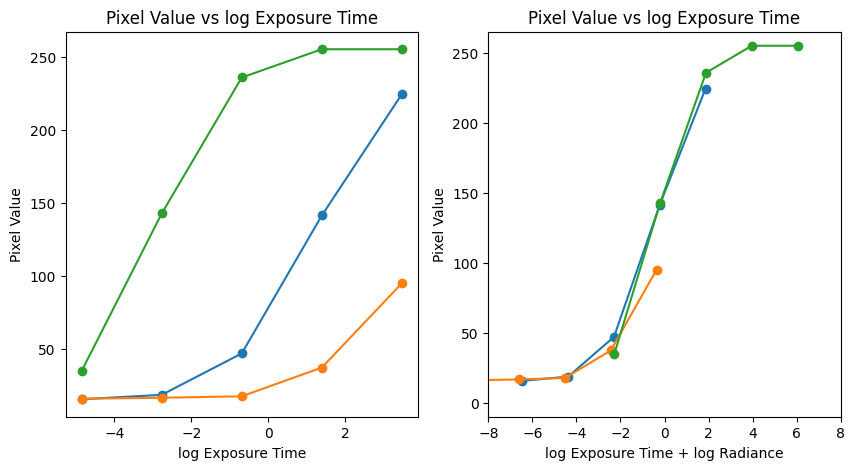

In [8]:
# 2.1.a

Plot_Pixel_Value_vs_Log_Exposure(f'{FOLDER_NAME}/TestImage/{TestImage}')

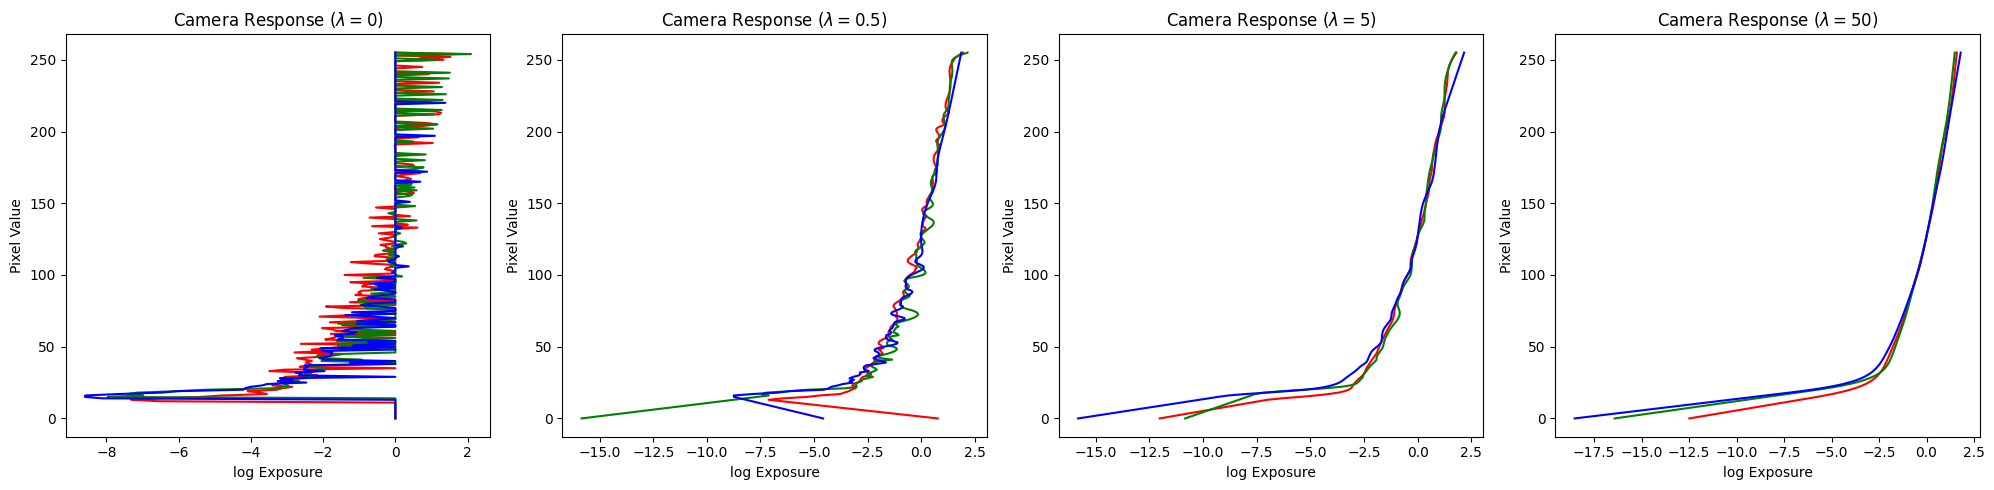

In [9]:
# 2.2.a

Plot_Response_Curve(f'{FOLDER_NAME}/TestImage/{TestImage}')

In [10]:
# 2.1.c

TestImage = 'my_test_images'

print(f'---------- Test Image is {TestImage} ----------')
### Whole HDR flow ###
print('Start to process HDR flow...')

# Camera response calibration
radiance = Camera_Response_Calibration(f'{FOLDER_NAME}/TestImage/{TestImage}', lambda_=50)
print('--Camera response calibration done')

# White balance
ktbw = (1285, 1303), (575, 735) # ktbw region for my test image

radiance_wb = White_Balance(radiance.copy(), *ktbw)
print('--White balance done')
print('--Tone mapping')

# Global tone mapping
gtm_no_wb = Global_Tone_Mapping(radiance, scale=1)  # without white balance
gtm = Global_Tone_Mapping(radiance_wb, scale=1)     # with white balance
print('  --Global tone mapping done')

# Local tone mapping with gaussian filter
ltm_filter = partial(Gaussian_Filter, N=15, sigma_s=100)
ltm_gaussian = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with gaussian filter done')

# Local tone mapping with bilateral filter
ltm_filter = partial(Bilateral_Filter, N=15, sigma_s=100, sigma_r=0.8)
ltm_bilateral = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with bilateral filter done')
print('Whole process done\n')

### Save result ###
print('Saving results...')
SaveImg(gtm_no_wb, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_gtm_no_wb.png')
SaveImg(gtm, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_gtm.png')
SaveImg(ltm_gaussian, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_ltm_gau.png')
SaveImg(ltm_bilateral, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_ltm_bil.png')
print(f'All results are saved @ {FOLDER_NAME}/MyHDR_result/')

---------- Test Image is my_test_images ----------
Start to process HDR flow...
--Camera response calibration done
--White balance done
--Tone mapping
  --Global tone mapping done
  --Local tone mapping with gaussian filter done
  --Local tone mapping with bilateral filter done
Whole process done

Saving results...
All results are saved @ hw01/MyHDR_result/


In [11]:
# Report 2.2.b

TestImage = 'my_test_images'

print(f'---------- Test Image is {TestImage} ----------')
### Whole HDR flow ###
print('Start to process HDR flow...')

# Camera response calibration
radiance = Camera_Response_Calibration(f'{FOLDER_NAME}/TestImage/{TestImage}', lambda_=50)
print('--Camera response calibration done')

# White balance
ktbw = (1285, 1303), (575, 735) # ktbw region for my test image

radiance_wb = White_Balance(radiance.copy(), *ktbw)
print('--White balance done')
print('--Tone mapping')

# CLAHE global tone mapping
gtm_no_wb = CLAHE_Global_Tone_Mapping(radiance, scale=1)  # without white balance
gtm = CLAHE_Global_Tone_Mapping(radiance_wb, scale=1)     # with white balance
print('  --CLAHE global tone mapping done')

# CLAHE local tone mapping with gaussian filter
ltm_filter = partial(Gaussian_Filter, N=15, sigma_s=100)
ltm_gaussian = CLAHE_Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --CLAHE local tone mapping with gaussian filter done')

# CLAHE local tone mapping with bilateral filter
ltm_filter = partial(Bilateral_Filter, N=15, sigma_s=100, sigma_r=0.8)
ltm_bilateral = CLAHE_Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --CLAHE local tone mapping with bilateral filter done')
print('Whole process done\n')

### Save result ###
print('Saving results...')
SaveImg(gtm_no_wb, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_CLAHEgtm_no_wb.png')
SaveImg(gtm, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_CLAHEgtm.png')
SaveImg(ltm_gaussian, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_CLAHEltm_gau.png')
SaveImg(ltm_bilateral, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_CLAHEltm_bil.png')
print(f'All results are saved @ {FOLDER_NAME}/MyHDR_result/')

---------- Test Image is my_test_images ----------
Start to process HDR flow...
--Camera response calibration done
--White balance done
--Tone mapping
  --CLAHE global tone mapping done
  --CLAHE local tone mapping with gaussian filter done
  --CLAHE local tone mapping with bilateral filter done
Whole process done

Saving results...
All results are saved @ hw01/MyHDR_result/


In [12]:
# 2.2.c (Original)

TestImage = 'my_test_images_artifacts'

print(f'---------- Test Image is {TestImage} ----------')
### Whole HDR flow ###
print('Start to process HDR flow...')

# Camera response calibration
radiance = Camera_Response_Calibration(f'{FOLDER_NAME}/TestImage/{TestImage}', lambda_=50)
print('--Camera response calibration done')

# White balance
ktbw = (1496, 2182), (416, 483) # ktbw region for my test image with artifacts

radiance_wb = White_Balance(radiance.copy(), *ktbw)
print('--White balance done')
print('--Tone mapping')

# Global tone mapping
gtm_no_wb = Global_Tone_Mapping(radiance, scale=1)  # without white balance
gtm = Global_Tone_Mapping(radiance_wb, scale=1)     # with white balance
print('  --Global tone mapping done')

# Local tone mapping with gaussian filter
ltm_filter = partial(Gaussian_Filter, N=15, sigma_s=100)
ltm_gaussian = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with gaussian filter done')

# Local tone mapping with bilateral filter
ltm_filter = partial(Bilateral_Filter, N=15, sigma_s=100, sigma_r=0.8)
ltm_bilateral = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with bilateral filter done')
print('Whole process done\n')

### Save result ###

SaveImg(gtm_no_wb, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_gtm_no_wb_artifacts.png')
SaveImg(gtm, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_gtm_artifacts.png')
SaveImg(ltm_gaussian, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_ltm_gau_artifacts.png')
SaveImg(ltm_bilateral, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_ltm_bil_artifacts.png')
print(f'All results are saved @ {FOLDER_NAME}/MyHDR_result/')

---------- Test Image is my_test_images_artifacts ----------
Start to process HDR flow...
--Camera response calibration done
--White balance done
--Tone mapping
  --Global tone mapping done
  --Local tone mapping with gaussian filter done


KeyboardInterrupt: 

In [ ]:
# 2.2.c (Optimized)

TestImage = 'my_test_images_artifacts'

print(f'---------- Test Image is {TestImage} ----------')
### Whole HDR flow ###
print('Start to process HDR flow...')

# Camera response calibration
radiance = Threshold_Camera_Response_Calibration(f'{FOLDER_NAME}/TestImage/{TestImage}', lambda_=50)
print('--Camera response calibration done')

# White balance
ktbw = (1496, 2182), (416, 483) # ktbw region for my test image with artifacts

radiance_wb = White_Balance(radiance.copy(), *ktbw)
print('--White balance done')
print('--Tone mapping')

# Global tone mapping
gtm_no_wb = Global_Tone_Mapping(radiance, scale=1)  # without white balance
gtm = Global_Tone_Mapping(radiance_wb, scale=1)     # with white balance
print('  --Global tone mapping done')

# Local tone mapping with gaussian filter
ltm_filter = partial(Gaussian_Filter, N=15, sigma_s=100)
ltm_gaussian = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with gaussian filter done')

# Local tone mapping with bilateral filter
ltm_filter = partial(Bilateral_Filter, N=15, sigma_s=100, sigma_r=0.8)
ltm_bilateral = Local_Tone_Mapping(radiance_wb, ltm_filter, scale=7)
print('  --Local tone mapping with bilateral filter done')
print('Whole process done\n')

### Save result ###

SaveImg(gtm_no_wb, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_gtm_no_wb_threshold.png')
SaveImg(gtm, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_gtm_threshold.png')
SaveImg(ltm_gaussian, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_ltm_gau_threshold.png')
SaveImg(ltm_bilateral, f'{FOLDER_NAME}/MyHDR_result/{TestImage}_ltm_bil_threshold.png')
print(f'All results are saved @ {FOLDER_NAME}/MyHDR_result/')